# Regression Of Used Car Prices

```markdown

This Jupyter Notebook serves as a guide for training a regression model to predict the price of a used car. The goal is to analyze various features of the car, such as its brand,milage,fuel type,accident, and other relevant factors, to estimate its market value accurately.

By leveraging machine learning techniques and a dataset containing historical car prices, we can build a predictive model that learns from the patterns and relationships within the data. This model can then be used to estimate the price of a used car based on its characteristics.

Throughout this notebook, we will explore the dataset, preprocess the data, perform feature engineering, train the regression model, and evaluate its performance. Additionally, we will visualize the data and model predictions to gain insights into the factors influencing car prices.

Let's get started with the data exploration and analysis!
```

In [1]:
# Import livraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, MaxAbsScaler, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer

## Load the dataset

In [2]:
used_cars = pd.read_csv('data/train.csv')
used_cars.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [3]:
used_cars.set_index('id', inplace=True)
used_cars.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


Now that we have load our data. It's important to know the number of data, features and missing values.

In [4]:
print("The number of used car prices are", used_cars.shape[0])
print("The number of variable are", used_cars.shape[1])

print("The number of missing values are \n", used_cars.isnull().sum())

The number of used car prices are 188533
The number of variable are 12
The number of missing values are 
 brand               0
model               0
model_year          0
milage              0
fuel_type        5083
engine              0
transmission        0
ext_col             0
int_col             0
accident         2452
clean_title     21419
price               0
dtype: int64


We can note here that there are missing values for fuel_type, accident, clean_title. During the analysis of those feature, a decision will be token to manage those missing values.

In [5]:
used_cars.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   167114 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 18.7+ MB


In [6]:
# Put objet column in lower case
used_cars['brand'] = used_cars['brand'].str.lower()
used_cars['model'] = used_cars['model'].str.lower()
used_cars['fuel_type'] = used_cars['fuel_type'].str.lower()
used_cars['engine'] = used_cars['engine'].str.lower()
used_cars['transmission'] = used_cars['transmission'].str.lower()
used_cars['ext_col'] = used_cars['ext_col'].str.lower()
used_cars['int_col'] = used_cars['int_col'].str.lower()
used_cars['accident'] = used_cars['accident'].str.lower()
used_cars['clean_title'] = used_cars['clean_title'].str.lower()

## Data Analysis

**Price**

To study the target "price", it's important to answer some questions:

- <span style="color:blue">What the average price of a used car ? </span>
- <span style="color:blue">What is the cheapest and the most expensive used car ? </span>

In [7]:
# Average price of used cars
avg_price = used_cars['price'].mean()
print("The average price of used cars is", round(avg_price))

The average price of used cars is 43878


In [8]:
# Cheapest and most expensive used cars
min_price = used_cars['price'].min()
max_price = used_cars['price'].max()
print("The cheapest used car is", min_price)
print("The most expensive used car is", max_price)

The cheapest used car is 2000
The most expensive used car is 2954083


<Axes: ylabel='price'>

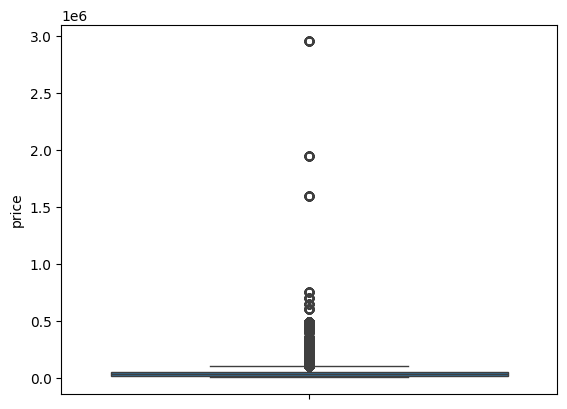

In [9]:
sns.boxplot(data=used_cars, y="price")

Let's have a look on those expensive cars

In [10]:
expensive_cars = used_cars[used_cars['price'] == max_price]
print("The number of most expensive cars are", expensive_cars.shape[0])
expensive_cars.head(10)

The number of most expensive cars are 50


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
220,ford,f-150 xlt,2021,26315,gasoline,3.5l v6 24v pdi dohc twin turbo,10-speed automatic,agate black metallic,black,none reported,yes,2954083
1880,chrysler,300c base,2003,55900,gasoline,340.0hp 5.7l 8 cylinder engine gasoline fuel,5-speed a/t,beige,beige,none reported,yes,2954083
13838,toyota,highlander se,2014,85000,gasoline,3.5l v6 24v pdi dohc,8-speed automatic,green,black,none reported,yes,2954083
14693,hyundai,santa fe sel,2022,13865,gasoline,2.5l i4 16v pdi dohc,8-speed automatic,black,black,none reported,yes,2954083
16034,mercedes-benz,sl-class sl500 roadster,2005,34068,gasoline,302.0hp 5.0l 8 cylinder engine gasoline fuel,7-speed a/t,white,beige,none reported,yes,2954083
18946,audi,s4 base,2004,73500,gasoline,340.0hp 4.2l 8 cylinder engine gasoline fuel,6-speed m/t,blue,beige,none reported,yes,2954083
21814,ram,1500 laramie,2022,16156,gasoline,5.7l v8 16v mpfi ohv,8-speed automatic,diamond black,black,none reported,NaN,2954083
36615,ford,excursion limited ultimate,2002,89900,diesel,325.0hp 6.0l 8 cylinder engine diesel fuel,5-speed a/t,gold,gold,none reported,yes,2954083
42177,ford,mustang gt,2005,82000,gasoline,300.0hp 4.6l 8 cylinder engine gasoline fuel,5-speed m/t,silver,black,none reported,yes,2954083


In [11]:
cheapest_car = used_cars[used_cars['price'] == min_price]
print("The number of cheapest cars are", cheapest_car.shape[0])
cheapest_car.head(10)

The number of cheapest cars are 56


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
758,pontiac,firebird trans am,2001,150000,gasoline,310.0hp 5.7l 8 cylinder engine gasoline fuel,a/t,black,beige,none reported,yes,2000
3681,toyota,camry hybrid base,2003,155000,hybrid,147.0hp 2.4l 4 cylinder engine gas/electric hy...,a/t,silver,beige,at least 1 accident or damage reported,yes,2000
4781,toyota,camry solara sle,2001,73690,gasoline,200.0hp 3.8l v6 cylinder engine gasoline fuel,a/t,black,gray,none reported,yes,2000
11146,chevrolet,monte carlo ss,2001,64776,gasoline,200.0hp 3.8l v6 cylinder engine gasoline fuel,4-speed a/t,gray,black,none reported,yes,2000
12655,mercedes-benz,slk-class slk320,2003,107000,gasoline,215.0hp 3.2l v6 cylinder engine gasoline fuel,5-speed a/t,black,black,none reported,yes,2000
17482,gmc,terrain slt-1,2003,90000,gasoline,181.0hp 2.5l 4 cylinder engine gasoline fuel,5-speed a/t,blue,beige,none reported,yes,2000
17849,acura,mdx touring,2007,116000,gasoline,260.0hp 3.5l v6 cylinder engine gasoline fuel,a/t,gray,brown,at least 1 accident or damage reported,yes,2000
18918,ford,dakota slt quad cab,2002,138000,gasoline,220.0hp 4.6l 8 cylinder engine gasoline fuel,a/t,blue,gray,none reported,yes,2000
19305,mitsubishi,eclipse spyder gt,2003,120000,gasoline,260.0hp 3.8l v6 cylinder engine gasoline fuel,a/t,black,black,at least 1 accident or damage reported,yes,2000


After a look on internet, we can see that some cars are too much expensive for the expected prices. So those data will be removed.

In [12]:
cleaned_cars = used_cars.copy()
cleaned_cars = cleaned_cars.drop(expensive_cars.index)
max_price = cleaned_cars['price'].max()
print("The most expensive used car is", max_price)
expensive_cars = cleaned_cars[cleaned_cars['price'] == max_price]
print("The number of most expensive cars are", expensive_cars.shape[0])
expensive_cars.head(10)

The most expensive used car is 1950995
The number of most expensive cars are 47


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
id,,,,,,,,,,,,
2964,porsche,911 r,2023,714,gasoline,4.0l h6 24v gdi dohc,6-speed manual,white,gray,none reported,yes,1950995
8789,lamborghini,gallardo lp570-4 superleggera,2011,3254,gasoline,5.2l v10 40v gdi dohc,7-speed automatic with auto-shift,nero noctis,nero ade,none reported,yes,1950995
10173,mercedes-benz,amg gls 63 4matic,2019,4102,gasoline,603.0hp 4.0l 8 cylinder engine gasoline fuel,9-speed a/t,red,black,none reported,yes,1950995
21523,bmw,m3 cs,2018,7500,gasoline,543.0hp 3.0l straight 6 cylinder engine gasoli...,transmission w/dual shift mode,silver,black,none reported,yes,1950995
31429,chevrolet,corvette base,2002,15443,gasoline,400.0hp 6.0l 8 cylinder engine gasoline fuel,6-speed a/t,black,beige,none reported,yes,1950995
32645,bentley,continental gt speed,2016,27981,gasoline,6.0l w12 48v pdi dohc twin turbo,8-speed automatic,–,hotspur,NaN,NaN,1950995
32903,bentley,continental gtc base,2012,18000,e85 flex fuel,552.0hp 6.0l 12 cylinder engine flex fuel capa...,6-speed a/t,black,black,NaN,NaN,1950995
34801,mercedes-benz,sl-class sl550 roadster,2004,13250,gasoline,382.0hp 5.5l 8 cylinder engine gasoline fuel,a/t,white,beige,none reported,yes,1950995
35218,chevrolet,corvette base,2010,34500,gasoline,400.0hp 6.0l 8 cylinder engine gasoline fuel,transmission w/dual shift mode,blue,blue,at least 1 accident or damage reported,yes,1950995


Now that the most expensive cars are "luxury" brands, we can assume that the prices are "fair".

<Axes: ylabel='price'>

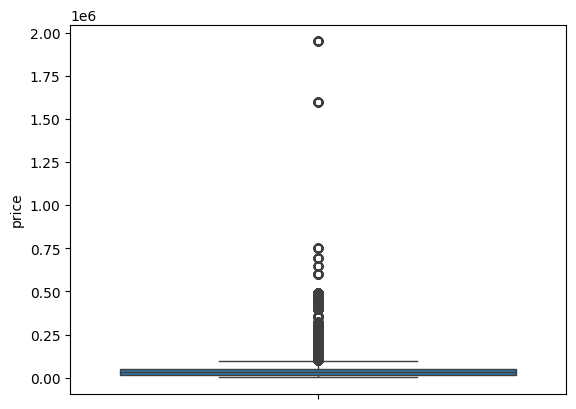

In [13]:
sns.boxplot(data=cleaned_cars, y="price")

**Brand**

To study the feature "brand", it's important to answer some questions:

- <span style="color:blue">What is the number of brands present in the dataset? </span>
- <span style="color:blue">What is the most and the least brand present in the dataset? </span>

In [14]:
# number of brands
brands = cleaned_cars['brand'].unique()
print("The number of brands are", len(brands))

The number of brands are 57


In [15]:
# average number of cars per brand
avg_cars_per_brand = cleaned_cars['brand'].value_counts().mean()
print("The average number of cars per brand are", round(avg_cars_per_brand))

The average number of cars per brand are 3307


<Axes: xlabel='count', ylabel='brand'>

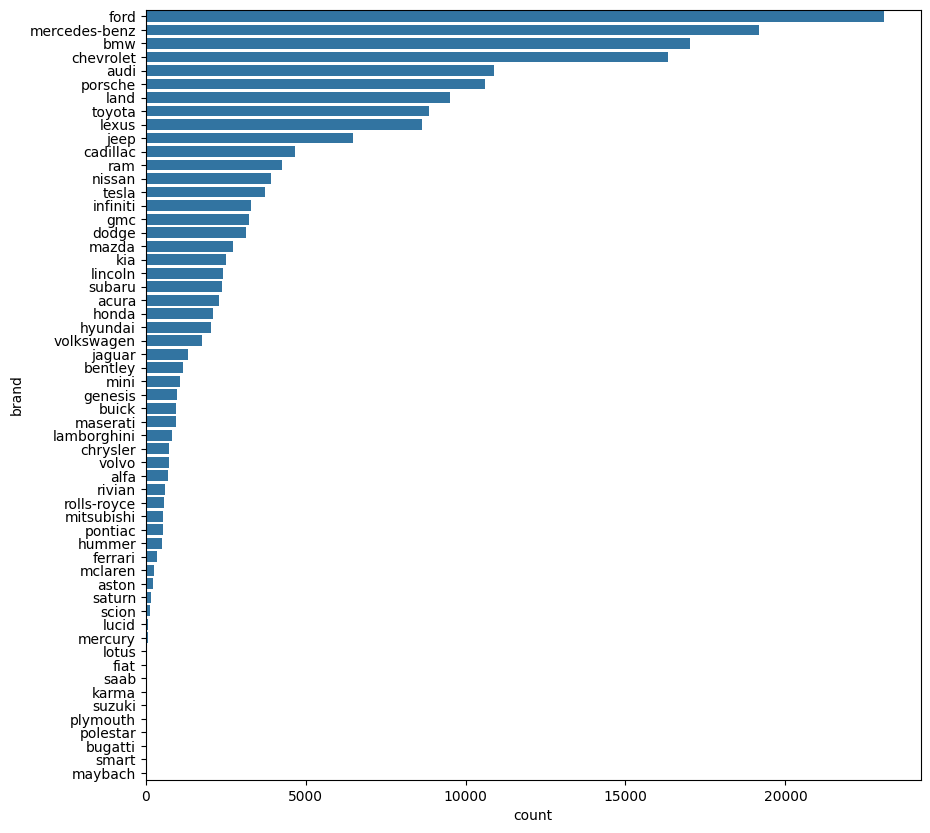

In [16]:
plt.figure(figsize=(10, 10))
sns.countplot(data=cleaned_cars, y="brand", order=cleaned_cars['brand'].value_counts().index)

In [17]:
# most and least present brands
most_present_brand = cleaned_cars['brand'].value_counts().idxmax()
least_present_brand = cleaned_cars['brand'].value_counts().idxmin()
print("The most present brand is", most_present_brand)
print("The least present brand is", least_present_brand)

The most present brand is ford
The least present brand is smart


<Axes: xlabel='price', ylabel='brand'>

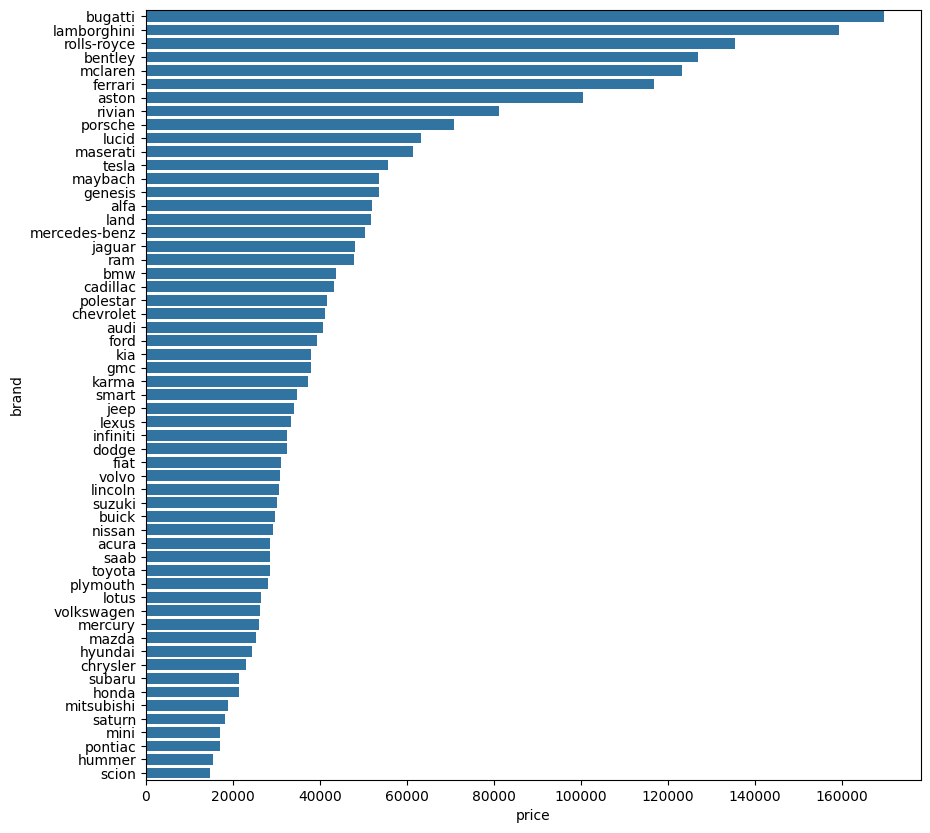

In [18]:
# average price of cars per brand
avg_price_per_brand = cleaned_cars.groupby('brand')['price'].mean().round().sort_values(ascending=False)
plt.figure(figsize=(10, 10))
sns.barplot(x=avg_price_per_brand, y=avg_price_per_brand.index)

These graphs highlight the fact that most under-represented brands have higher average prices.

A new category called "Others" will be create for all cars less present that 30% of the average cars per brand

In [19]:
# Create a new column to add the category 'other' for brands with less than 100 cars
brand_counts = cleaned_cars['brand'].value_counts()
other_brands = brand_counts[brand_counts < (avg_cars_per_brand*0.3)].index
cleaned_cars['brand_nw'] = cleaned_cars['brand'].replace(other_brands, 'other')

<Axes: xlabel='count', ylabel='brand_nw'>

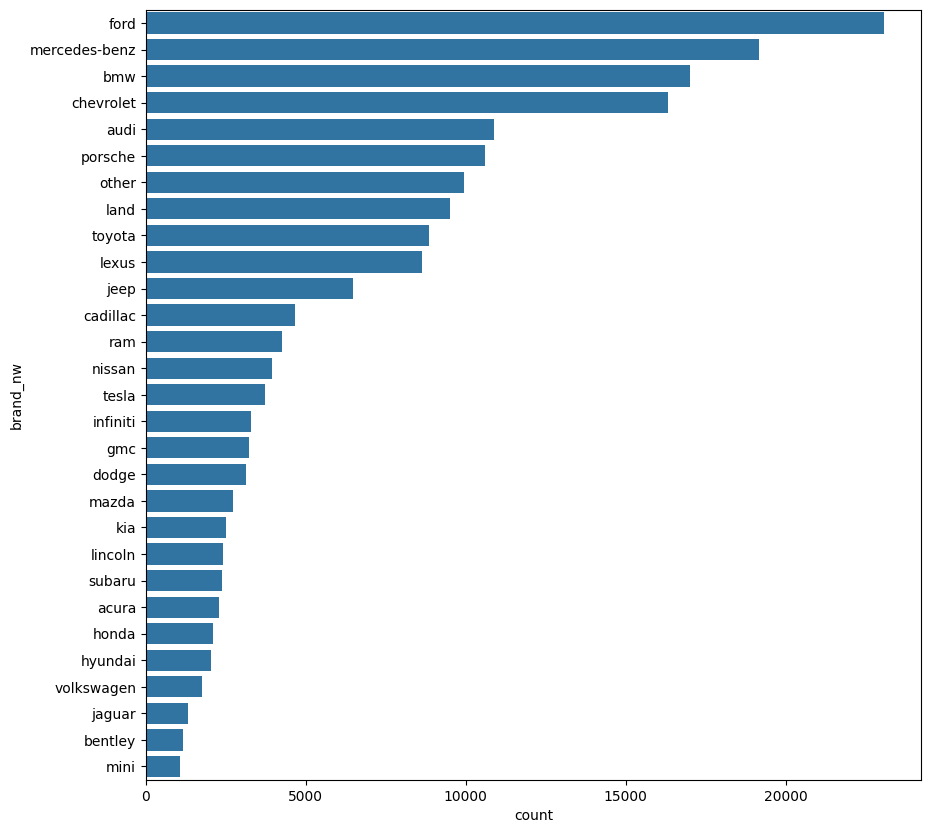

In [20]:
plt.figure(figsize=(10, 10))
sns.countplot(data=cleaned_cars, y="brand_nw", order=cleaned_cars['brand_nw'].value_counts().index)

In [21]:
# brand_cat
brand_cat = cleaned_cars['brand_nw'].unique()
brand_cat

array(['mini', 'lincoln', 'chevrolet', 'other', 'mercedes-benz', 'audi',
       'ford', 'bmw', 'tesla', 'cadillac', 'land', 'gmc', 'toyota',
       'hyundai', 'volkswagen', 'ram', 'infiniti', 'jeep', 'porsche',
       'honda', 'lexus', 'dodge', 'nissan', 'jaguar', 'acura', 'kia',
       'bentley', 'mazda', 'subaru'], dtype=object)

**Model**

To study the feature "model", it's important to answer some questions:

- <span style="color:blue">What is the number of brands present in the dataset? </span>
- <span style="color:blue">What is the most and the least brand present in the dataset? </span>

In [22]:
# number of models
models = cleaned_cars['model'].unique()
print("The number of models are", len(models))

The number of models are 1893


In [23]:
# number of data per model
data_per_model = cleaned_cars['model'].value_counts()
print("The average number of data per model are", round(data_per_model.mean()))

The average number of data per model are 100


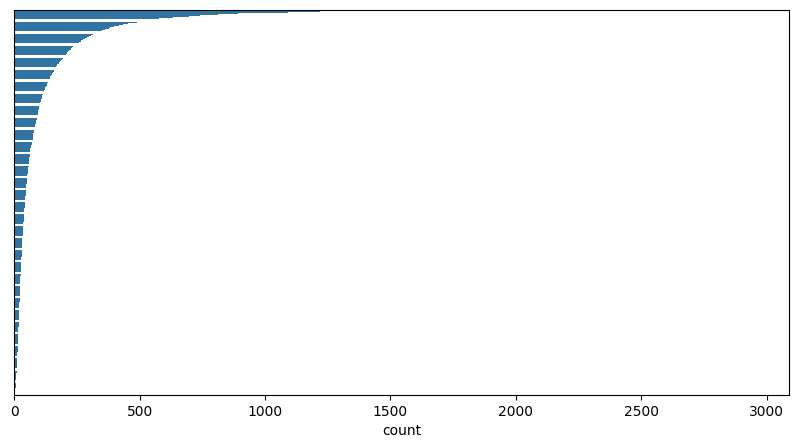

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="model", order=cleaned_cars['model'].value_counts().index).yaxis.set_visible(False)

In [25]:
# number of models per brand
models_per_brand = cleaned_cars.groupby('brand')['model'].nunique()
print("The number of models per brand are \n", models_per_brand.sort_values(ascending=False))

The number of models per brand are 
 brand
ford             302
mercedes-benz    265
bmw              255
chevrolet        237
toyota           224
audi             183
nissan           178
porsche          158
lexus            130
cadillac         104
dodge             96
volkswagen        92
acura             85
land              83
lincoln           82
jeep              78
honda             71
kia               71
hyundai           70
gmc               69
mazda             67
infiniti          57
subaru            56
jaguar            50
ram               47
volvo             45
tesla             39
ferrari           33
buick             32
chrysler          32
maserati          30
lamborghini       27
bentley           26
genesis           25
mitsubishi        22
pontiac           19
mini              13
aston             11
scion             10
mclaren           10
fiat               8
lucid              7
rolls-royce        7
alfa               7
lotus              6
mercury     

In [26]:
# average number of models per brand
avg_models_per_brand = models_per_brand.mean()
print("The average number of models per brand are", round(avg_models_per_brand))

The average number of models per brand are 62


In [27]:
# Create a new column to add the category 'other' for brands with less than 20% of the average number of models
avg_models = cleaned_cars['model'].value_counts().mean()
model_counts = cleaned_cars['model'].value_counts()
other_models = model_counts[model_counts <= (avg_models*0.3)].index
cleaned_cars['model_nw'] = cleaned_cars['model'].replace(other_models, 'other')

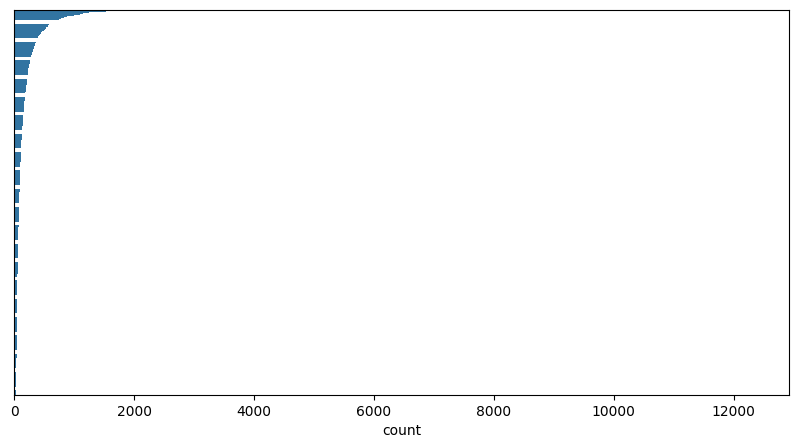

In [28]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="model_nw", order=cleaned_cars['model_nw'].value_counts().index).yaxis.set_visible(False)

In [29]:
# model_cat
model_cat = cleaned_cars['model_nw'].unique()
model_cat

array(['cooper s base', 'other', 'silverado 2500 lt', ...,
       'highlander le plus', 'rover range rover sport first edition',
       'tundra hybrid capstone'], dtype=object)

**Model year**

To study the feature "model_year", it's important to answer some questions:

- <span style="color:blue">What is the oldest and the most recent car? </span>
- <span style="color:blue">Is the age of the car link to his price? </span>

In [30]:
# oldest and newest cars
oldest_car = cleaned_cars['model_year'].min()
newest_car = cleaned_cars['model_year'].max()
print("The oldest car is", oldest_car)
print("The newest car is", newest_car)

The oldest car is 1974
The newest car is 2024


In [31]:
cleaned_cars[cleaned_cars['model_year'] == oldest_car].head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_nw,model_nw
id,,,,,,,,,,,,,,
8173,dodge,challenger r/t scat pack,1974,49000,–,–,5-speed m/t,green,gray,none reported,yes,29900,dodge,challenger r/t scat pack
38565,ford,bronco,1974,38012,–,–,–,thunder gray,dark gray,none reported,yes,84620,ford,bronco
47488,ford,bronco,1974,109762,gasoline,–,–,tempest,–,NaN,NaN,13046,ford,bronco
47837,ford,bronco xlt,1974,5856,–,–,6-speed m/t,black,black,none reported,yes,115000,ford,other
55169,ford,thunderbird deluxe,1974,174678,gasoline,280.0hp 3.9l 8 cylinder engine gasoline fuel,a/t,green,beige,none reported,yes,29998,ford,thunderbird deluxe


In [32]:
cleaned_cars[cleaned_cars['model_year'] == newest_car].head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_nw,model_nw
id,,,,,,,,,,,,,,
5570,lexus,nx 300h base,2024,16425,hybrid,2.5l i4 16v mpfi dohc hybrid,automatic cvt,black,gray,none reported,yes,44700,lexus,other
6143,bmw,330 i xdrive,2024,8700,gasoline,255.0hp 2.0l 4 cylinder engine gasoline fuel,a/t,blue,white,none reported,yes,33000,bmw,330 i xdrive
7164,bmw,m3 cs,2024,31850,gasoline,543.0hp 3.0l straight 6 cylinder engine gasoli...,transmission w/dual shift mode,black,black,none reported,yes,22550,bmw,m3 cs
7227,ford,expedition timberline,2024,23300,gasoline,440.0hp 3.5l v6 cylinder engine gasoline fuel,10-speed a/t,gray,black,none reported,yes,69500,ford,expedition timberline
7413,bmw,m3 cs,2024,34254,gasoline,543.0hp 3.0l straight 6 cylinder engine gasoli...,transmission w/dual shift mode,white,black,none reported,yes,63900,bmw,m3 cs


The better manage the model_year, we will work with the seniority

In [33]:
# Column for seniority (age of the car). The year 2024 is used as reference
cleaned_cars['seniority'] = 2024 - cleaned_cars['model_year']

# average seniority of cars
avg_seniority = cleaned_cars['seniority'].mean()
print("The average seniority of cars is", round(avg_seniority))

The average seniority of cars is 8


<Axes: xlabel='seniority'>

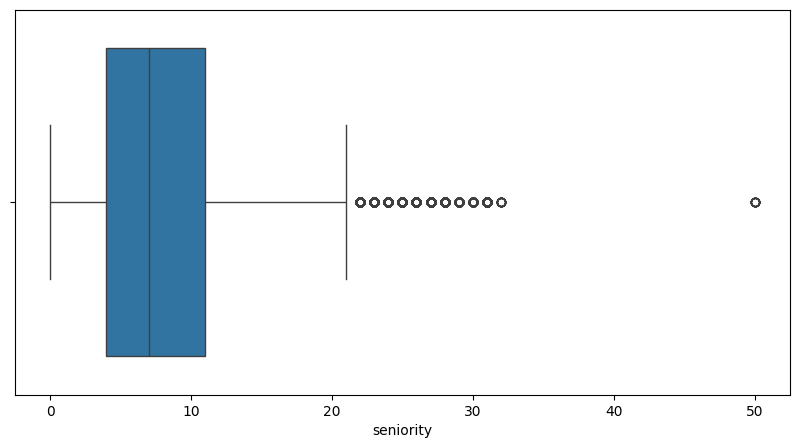

In [34]:
# plot of seniority
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="seniority")

<Axes: xlabel='seniority', ylabel='price'>

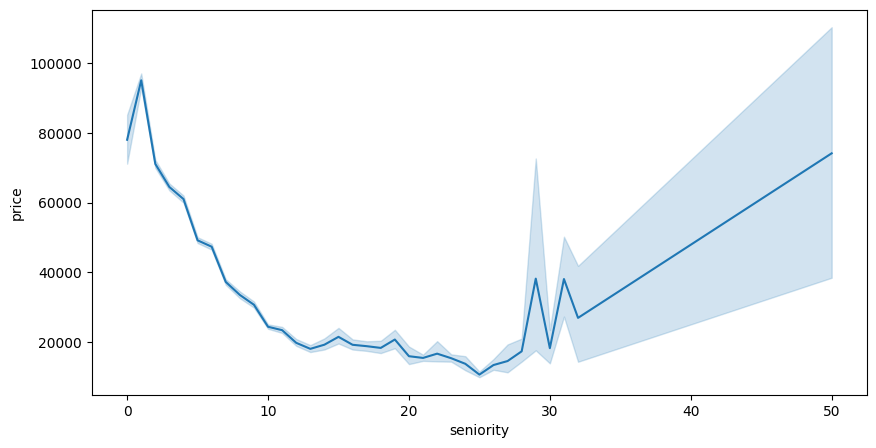

In [35]:
# Plot price average per seniority
plt.figure(figsize=(10, 5))
sns.lineplot(data=cleaned_cars, x="seniority", y="price")

As we can see the more a car is new the more it's expensive and the price are lower with time except for very old car

**Milage**

To study the feature "milage", it's important to answer some questions:

- <span style="color:blue">What is the car with the highest and the lowest milage? </span>
- <span style="color:blue">Is the milage of the car link to his price? </span>

In [36]:
# Highest and lowest milage
highest_mileage = cleaned_cars['milage'].max()
lowest_mileage = cleaned_cars['milage'].min()
print("The highest milage is", highest_mileage)
print("The lowest milage is", lowest_mileage)

The highest milage is 405000
The lowest milage is 100


In [37]:
cleaned_cars[cleaned_cars['milage'] == highest_mileage].head(10)

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_nw,model_nw,seniority
id,,,,,,,,,,,,,,,
24014,ford,f-150 xlt,2018,405000,e85 flex fuel,385.0hp 5.0l 8 cylinder engine flex fuel capab...,6-speed a/t,white,gray,at least 1 accident or damage reported,yes,35000,ford,f-150 xlt,6
36080,chevrolet,camaro 1ss,2019,405000,gasoline,455.0hp 6.2l 8 cylinder engine gasoline fuel,6-speed m/t,orange,black,none reported,yes,71950,chevrolet,camaro 1ss,5
45077,toyota,tacoma trd sport,2018,405000,gasoline,278.0hp 3.5l v6 cylinder engine gasoline fuel,6-speed m/t,black,black,none reported,yes,30000,toyota,tacoma trd sport,6
45288,toyota,tacoma trd sport,2018,405000,gasoline,278.0hp 3.5l v6 cylinder engine gasoline fuel,6-speed a/t,black,black,none reported,yes,20995,toyota,tacoma trd sport,6
61730,porsche,911 carrera cabriolet,1998,405000,gasoline,300.0hp 3.4l flat 6 cylinder engine gasoline fuel,6-speed m/t,blue,black,none reported,yes,124995,porsche,911 carrera cabriolet,26
126917,volvo,s40 t5,2005,405000,gasoline,218.0hp 2.5l 5 cylinder engine gasoline fuel,6-speed m/t,gold,beige,none reported,yes,10500,other,s40 t5,19
137357,volkswagen,golf gti 2.0t se 4-door,2016,405000,gasoline,240.0hp 2.0l 4 cylinder engine gasoline fuel,6-speed m/t,blue,black,none reported,yes,18000,volkswagen,golf gti 2.0t se 4-door,8
161337,volkswagen,cc 2.0t sport,2016,405000,gasoline,200.0hp 2.0l 4 cylinder engine gasoline fuel,8-speed a/t,white,gray,at least 1 accident or damage reported,yes,17500,volkswagen,cc 2.0t sport,8


In [38]:
cleaned_cars[cleaned_cars['milage'] == lowest_mileage].head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,brand_nw,model_nw,seniority
id,,,,,,,,,,,,,,,
13505,toyota,land cruiser base,2016,100,gasoline,381.0hp 5.7l 8 cylinder engine gasoline fuel,6-speed a/t,white,beige,none reported,yes,99000,toyota,land cruiser base,8
15805,lexus,rx 350 base,2022,100,gasoline,295.0hp 3.5l v6 cylinder engine gasoline fuel,6-speed a/t,silver,black,none reported,yes,66200,lexus,rx 350 base,2
20294,audi,q8 55 premium plus,2023,100,hybrid,335.0hp 3.0l v6 cylinder engine gasoline/mild ...,8-speed a/t,gray,red,none reported,yes,75000,audi,q8 55 premium plus,1
26319,chevrolet,corvette stingray w/1lt,2021,100,gasoline,490.0hp 6.2l 8 cylinder engine gasoline fuel,a/t,white,beige,at least 1 accident or damage reported,yes,60500,chevrolet,corvette stingray w/1lt,3
28114,porsche,911 carrera s,2023,100,gasoline,3.0l h6 24v gdi dohc twin turbo,8-speed automatic,red,black,none reported,NaN,77430,porsche,911 carrera s,1


<Axes: xlabel='milage'>

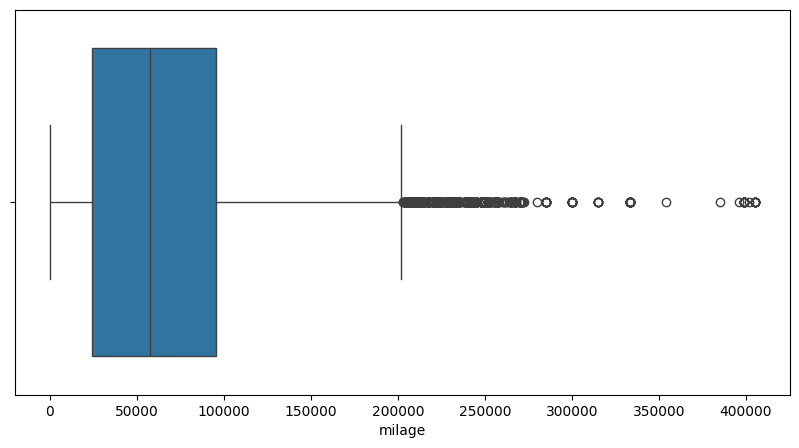

In [39]:
# Plot of milage
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="milage")

C:\Users\rtcho\AppData\Local\Temp\ipykernel_18284\327480014.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  milage_price_avg = cleaned_cars.groupby(milage_bins)['price'].mean().reset_index()


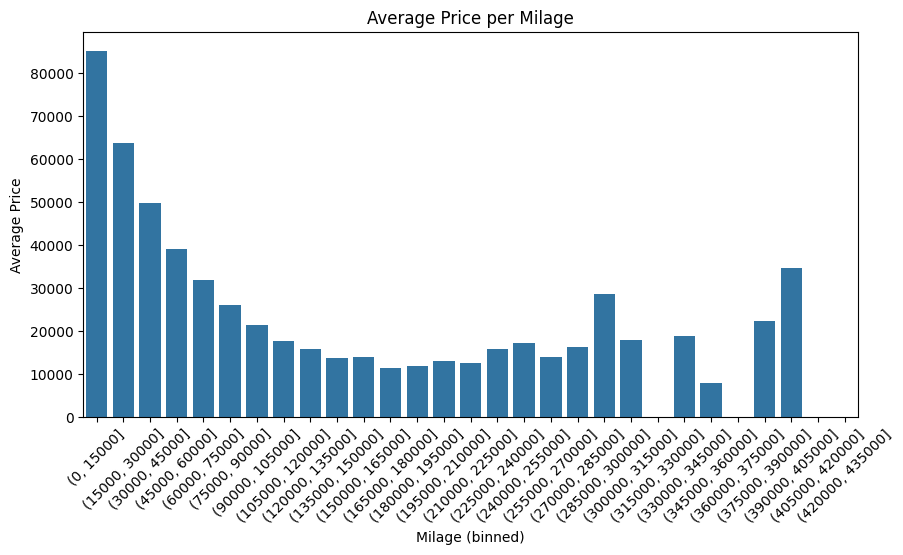

In [40]:
# Create milage bins (grouping milage into intervals of 15,000)
milage_bins = pd.cut(cleaned_cars['milage'], bins=range(0, 450000, 15000))

# Calculate the average price for each milage bin
milage_price_avg = cleaned_cars.groupby(milage_bins)['price'].mean().reset_index()

# Plotting the average price per milage bin
plt.figure(figsize=(10, 5))
sns.barplot(data=milage_price_avg, x="milage", y="price")

plt.title('Average Price per Milage')
plt.xlabel('Milage (binned)')
plt.ylabel('Average Price')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

Data with lower milage have highest price

**Fuel**

To study the feature "fuel_type", it's important to answer some questions:

- <span style="color:blue">How many type on fuel do we have? </span>
- <span style="color:blue">Is the fuel type link to the price? </span>

In [41]:
# Number of fuel type
fuel_types = cleaned_cars['fuel_type'].unique()
print("The number of fuel types are", len(fuel_types))

The number of fuel types are 8


In [42]:
fuel_types

array(['gasoline', 'e85 flex fuel', nan, 'hybrid', 'diesel',
       'plug-in hybrid', '–', 'not supported'], dtype=object)

<Axes: xlabel='count', ylabel='fuel_type'>

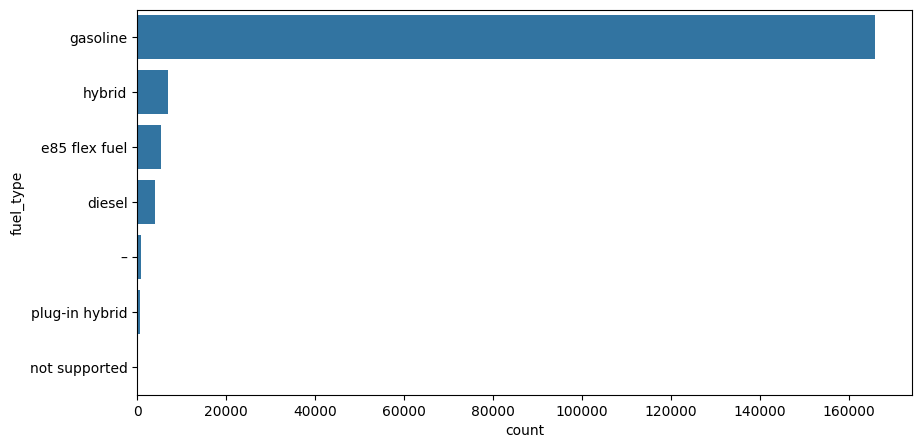

In [43]:
# Plot of fuel type
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="fuel_type", order=cleaned_cars['fuel_type'].value_counts().index)

<Axes: xlabel='price', ylabel='fuel_type'>

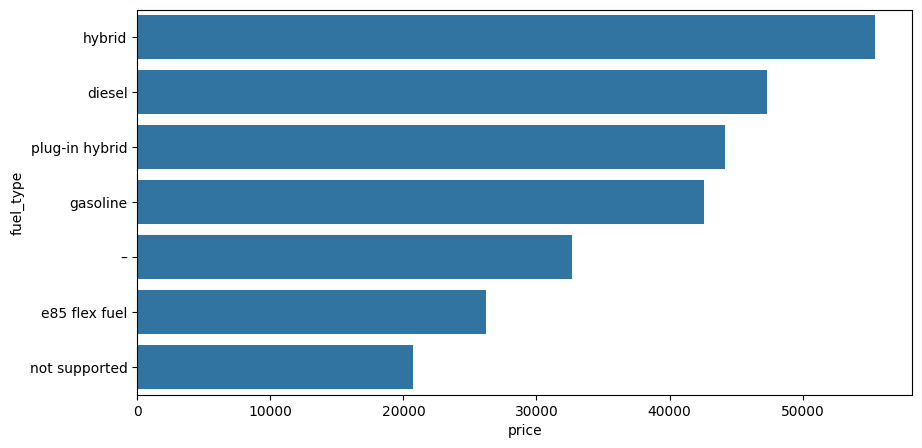

In [44]:
# Average price per fuel type
avg_price_per_fuel = cleaned_cars.groupby('fuel_type')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_price_per_fuel, y=avg_price_per_fuel.index)

In [45]:
# Function to combine some fuel types
def extract_fuel_type(fuel_types):
    fuel_types = str(fuel_types).lower()  # Convert to lowercase for easy matching
    if 'hybrid' in fuel_types:
        return 'Hybrid'
    elif 'gasoline' in fuel_types or 'e85 flex' in fuel_types:
        return 'Gasoline'
    elif 'diesel' in fuel_types:
        return 'Diesel'
    else:
        return 'Other'  # Handle cases like 'SCHEDULED FOR OR IN PRODUCTION'

# Apply the function to create a new column 'transmission_type'
cleaned_cars['fuel_type_nw'] = cleaned_cars['fuel_type'].apply(extract_fuel_type)

<Axes: xlabel='count', ylabel='fuel_type_nw'>

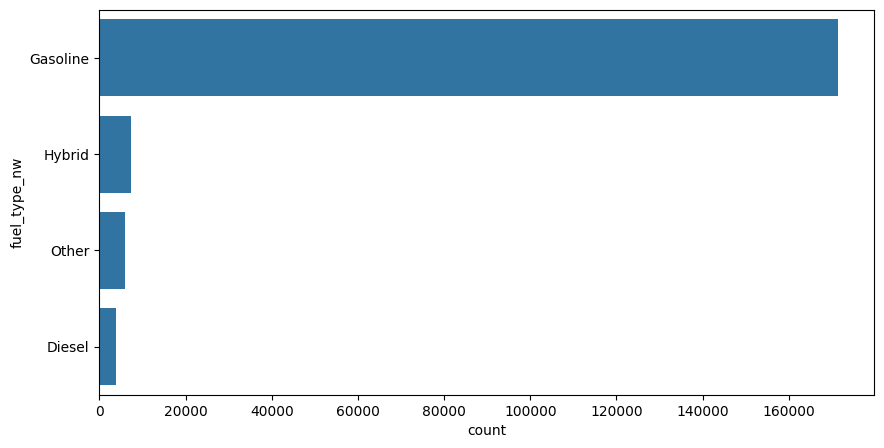

In [46]:
# Plot of fuel type
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="fuel_type_nw", order=cleaned_cars['fuel_type_nw'].value_counts().index)

In [47]:
# fuel_type_cat
fuel_type_cat = cleaned_cars['fuel_type_nw'].unique()
fuel_type_cat

array(['Gasoline', 'Other', 'Hybrid', 'Diesel'], dtype=object)

**Transmission**

To study the feature "transmission", it's important to answer some questions:

- <span style="color:blue">How many type on transmission do we have? </span>
- <span style="color:blue">Is the type of transmission link to the price? </span>

In [48]:
# Number of transmission
transmission = cleaned_cars['transmission'].unique()
print("The number of transmission are", len(transmission))

The number of transmission are 51


In [49]:
transmission

array(['a/t', 'transmission w/dual shift mode', '7-speed a/t',
       '8-speed a/t', '10-speed automatic', '1-speed a/t', '6-speed a/t',
       '10-speed a/t', '9-speed a/t', '8-speed automatic',
       '9-speed automatic', '5-speed a/t', 'automatic',
       '7-speed automatic with auto-shift', 'cvt transmission',
       '5-speed m/t', 'm/t', '6-speed m/t', '6-speed automatic',
       '4-speed automatic', '7-speed m/t', '2-speed a/t',
       '1-speed automatic', 'automatic cvt', '4-speed a/t',
       '6-speed manual', 'transmission overdrive switch',
       '8-speed automatic with auto-shift', '7-speed manual',
       '7-speed automatic', '9-speed automatic with auto-shift',
       '6-speed automatic with auto-shift',
       '6-speed electronically controlled automatic with o', 'f', 'cvt-f',
       '8-speed manual', 'manual', '–', '2', '6 speed at/mt',
       '5-speed automatic', '2-speed automatic', '7-speed', 'variable',
       'single-speed fixed gear', '8-speed at',
       '10-spee

Here we can extract some informations to create new features as the type of transmission (Manual or mt, automatic or A/T and others), the number of speed (0 to 10, 0 stand for not mention), additionnal fonction (Yes or No - Dual Shift Mode, Auto-shift, Overdrive, DCT, not mention)

In [50]:
# Replace Single by 1
cleaned_cars['transmission'] = cleaned_cars['transmission'].replace('Single-Speed Fixed Gear', '1-Speed Fixed Gear')
cleaned_cars['transmission'].unique()

array(['a/t', 'transmission w/dual shift mode', '7-speed a/t',
       '8-speed a/t', '10-speed automatic', '1-speed a/t', '6-speed a/t',
       '10-speed a/t', '9-speed a/t', '8-speed automatic',
       '9-speed automatic', '5-speed a/t', 'automatic',
       '7-speed automatic with auto-shift', 'cvt transmission',
       '5-speed m/t', 'm/t', '6-speed m/t', '6-speed automatic',
       '4-speed automatic', '7-speed m/t', '2-speed a/t',
       '1-speed automatic', 'automatic cvt', '4-speed a/t',
       '6-speed manual', 'transmission overdrive switch',
       '8-speed automatic with auto-shift', '7-speed manual',
       '7-speed automatic', '9-speed automatic with auto-shift',
       '6-speed automatic with auto-shift',
       '6-speed electronically controlled automatic with o', 'f', 'cvt-f',
       '8-speed manual', 'manual', '–', '2', '6 speed at/mt',
       '5-speed automatic', '2-speed automatic', '7-speed', 'variable',
       'single-speed fixed gear', '8-speed at',
       '10-spee

In [51]:
# Function to categorize transmission types
def extract_transmission_type(transmission):
    transmission = transmission.lower()  # Convert to lowercase for easy matching
    if 'manual' in transmission or 'm/t' in transmission or 'mt' in transmission:
        return 'Manual'
    elif 'a/t' in transmission or 'automatic' in transmission or 'at' in transmission:
        return 'Automatic'
    else:
        return 'Other'  # Handle cases like 'SCHEDULED FOR OR IN PRODUCTION'

# Apply the function to create a new column 'transmission_type'
cleaned_cars['transmission_type'] = cleaned_cars['transmission'].apply(extract_transmission_type)


<Axes: xlabel='count', ylabel='transmission_type'>

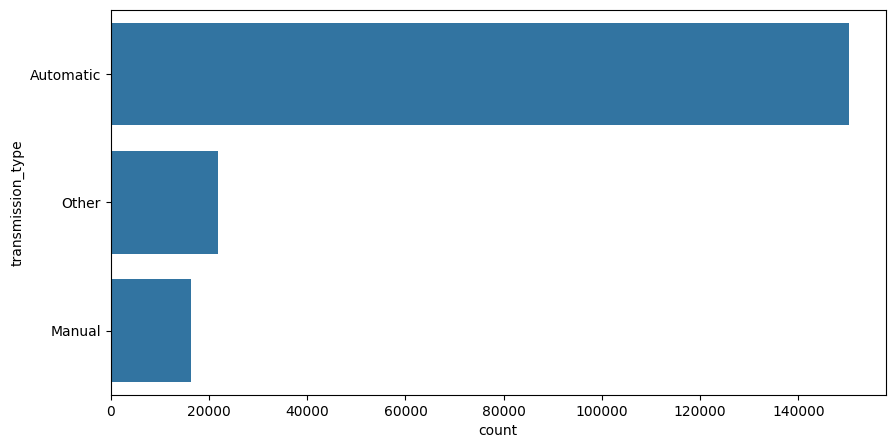

In [52]:
# Plot the distribution of transmission types
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="transmission_type")

<Axes: xlabel='transmission_type', ylabel='price'>

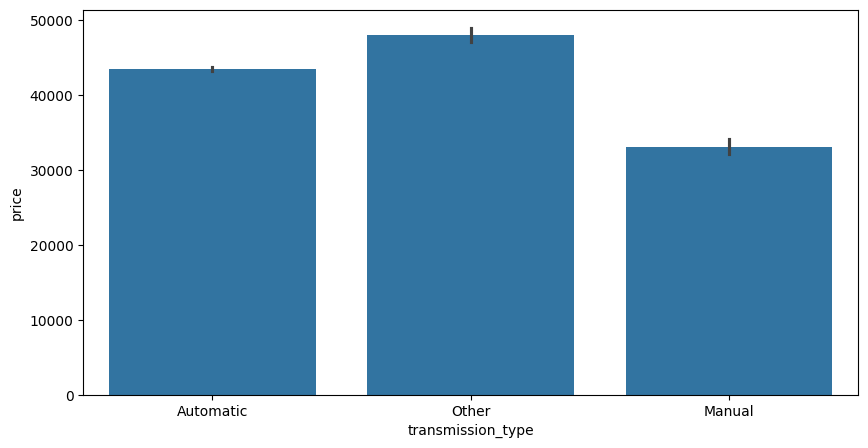

In [53]:
# Plot the average price per transmission type
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="transmission_type", y="price")

In [54]:
# transmission_type
transmission_type = cleaned_cars['transmission_type'].unique()
transmission_type

array(['Automatic', 'Other', 'Manual'], dtype=object)

In [55]:
# Function to extract number of speeds
def extract_number_of_speeds(transmission):
    match = re.search(r'(\d+)-speed', transmission.lower())  # Use regex to find number followed by '-speed'
    if match:
        return int(match.group(1))  # Return the number if found
    else:
        return 0  # Return 0 if no speed is mentioned

# Apply the function to create a new column 'num_speeds'
cleaned_cars['num_speeds'] = cleaned_cars['transmission'].apply(extract_number_of_speeds)

<Axes: xlabel='num_speeds'>

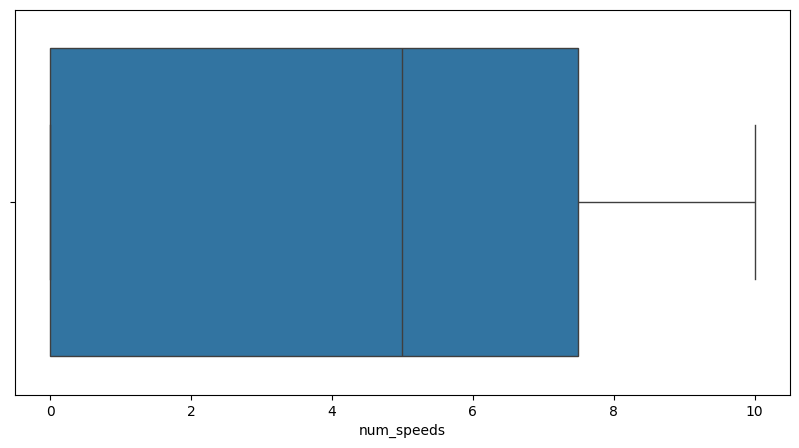

In [56]:
# Plot the distribution of the number of speeds
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="num_speeds")

<Axes: xlabel='num_speeds', ylabel='price'>

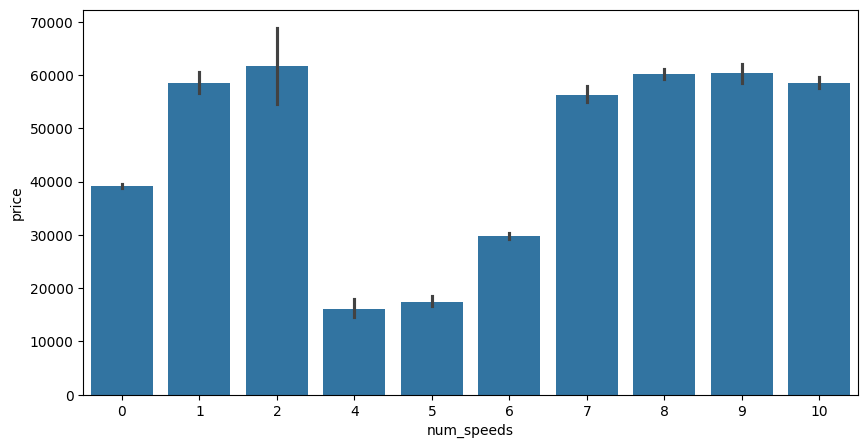

In [57]:
# Plot the average price per number of speeds
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="num_speeds", y="price")

In [58]:
# Function for additional transmission details
def has_additionnal(transmission):
    transmission = transmission.lower()
    if 'w' in transmission:
        return 1
    else:
        return 0

# Apply the function to create a new column 'additional_details'
cleaned_cars['additional_details'] = cleaned_cars['transmission'].apply(has_additionnal)

<Axes: xlabel='count', ylabel='additional_details'>

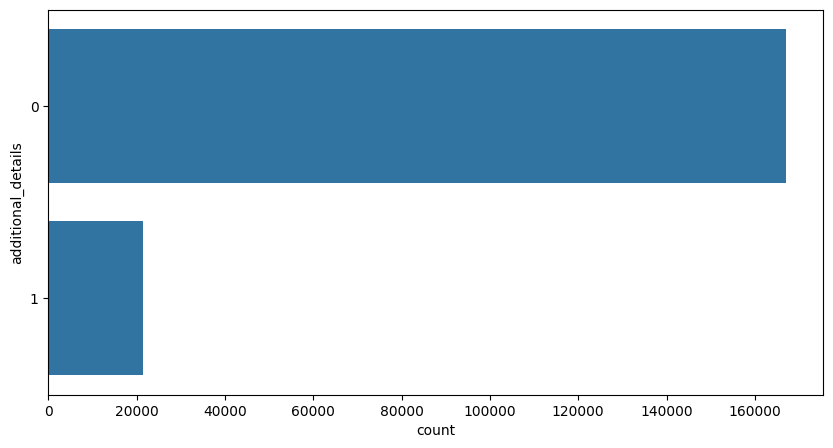

In [59]:
# Plot the distribution of transmission types
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="additional_details")

<Axes: xlabel='additional_details', ylabel='price'>

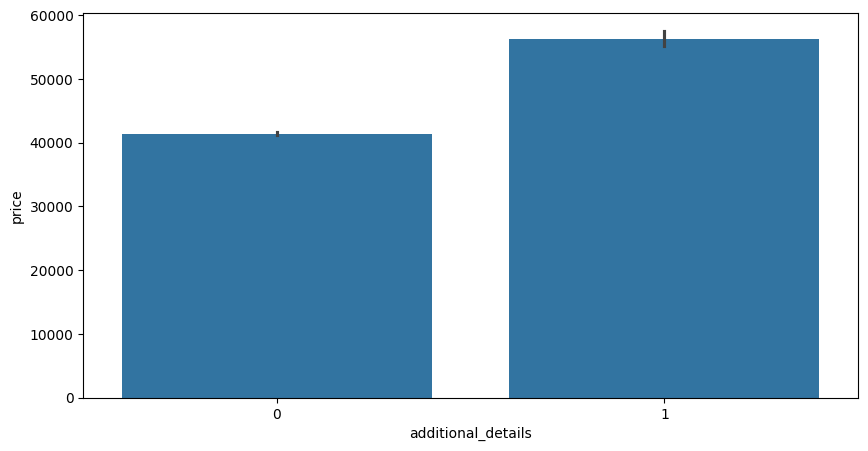

In [60]:
# Plot the average price per transmission with additional details
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="additional_details", y="price")

**Engine**

To study the feature "engine", it's important to answer some questions:

- <span style="color:blue">How many type on engine do we have? </span>
- <span style="color:blue">Is the type of engine link to the price? </span>

In [61]:
# Number of engine
engine = cleaned_cars['engine'].unique()
print("The number of engine are", len(engine))

The number of engine are 1117


In [62]:
engine

array(['172.0hp 1.6l 4 cylinder engine gasoline fuel',
       '252.0hp 3.9l 8 cylinder engine gasoline fuel',
       '320.0hp 5.3l 8 cylinder engine flex fuel capability', ...,
       '78.0hp 1.2l 3 cylinder engine gasoline fuel',
       '139.0hp 1.6l 4 cylinder engine plug-in electric/gas',
       '313.0hp 2.0l 4 cylinder engine plug-in electric/gas'],
      dtype=object)

In [63]:
# Function to extract the HP (which is a decimal number followed by 'HP' on the format 'xxx.xhp')
def extract_hp(engine):
    match = re.search(r'(\d+\.\d+)hp', str(engine).lower())  # Use regex to find number followed by 'hp'
    if match:
        return float(match.group(1))  # Return the number if found
    else:
        return 0  # Return 0 if no hp is mentioned

# Apply the function to create a new column 'hp'
cleaned_cars['hp'] = cleaned_cars['engine'].apply(extract_hp)

<Axes: xlabel='hp'>

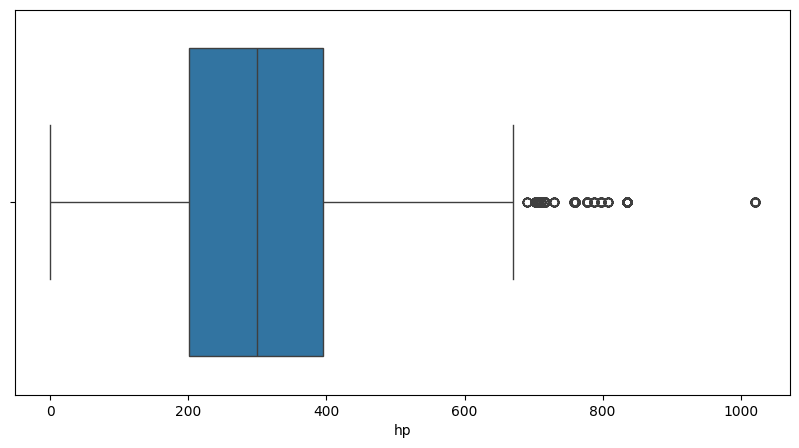

In [64]:
# Plot the distribution of hp
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="hp")

In [65]:
# Funtion to extract the number of cylinders (which is a number followed by ' cylinder' or 'V' followed by a number or 'H' followed by a number)

def extract_cylinders(engine):
    # Use regex to capture number followed by 'cylinder' or letter (v/h/i) followed by a number
    match = re.search(r'(\d+)\s*cylinder|[vhi](\d+)', engine.lower())
    
    if match:
        # Check if the first capturing group (number before 'cylinder') is not None
        if match.group(1) is not None:
            return int(match.group(1))
        # Check if the second capturing group (number after v/h/i) is not None
        elif match.group(2) is not None:
            return int(match.group(2))
    
    # Return 0 if no match was found
    return 0
    
# Apply the function to create a new column 'cylinders'
cleaned_cars['cylinders'] = cleaned_cars['engine'].apply(extract_cylinders)

<Axes: xlabel='cylinders'>

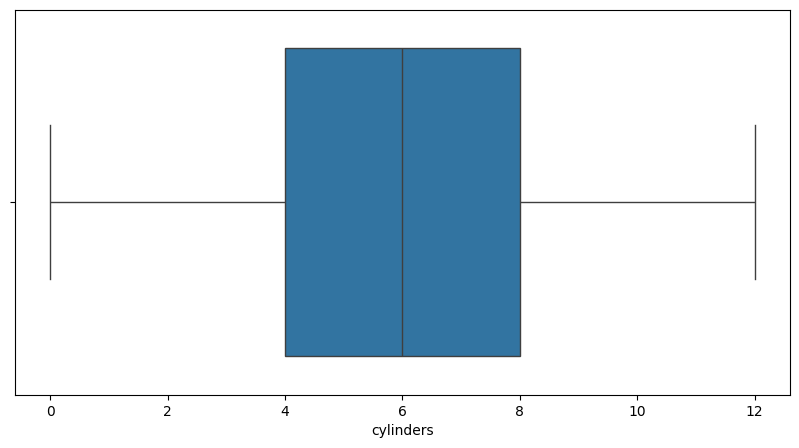

In [66]:
# Plot the distribution of the cylinders
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="cylinders")

In [67]:
# Function to extract the displacement (which is a decimal number followed by 'L' on the format 'x.xL')
def extract_displacement(engine):
    match = re.search(r'(\d+\.\d+)\s*[l|liter]', engine.lower())  # Use regex to find number followed by 'l'
    if match:
        return float(match.group(1))  # Return the number if found
    else:
        return 0  # Return 0 if no displacement is mentioned
    
# Apply the function to create a new column 'displacement'
cleaned_cars['displacement'] = cleaned_cars['engine'].apply(extract_displacement)

<Axes: xlabel='displacement'>

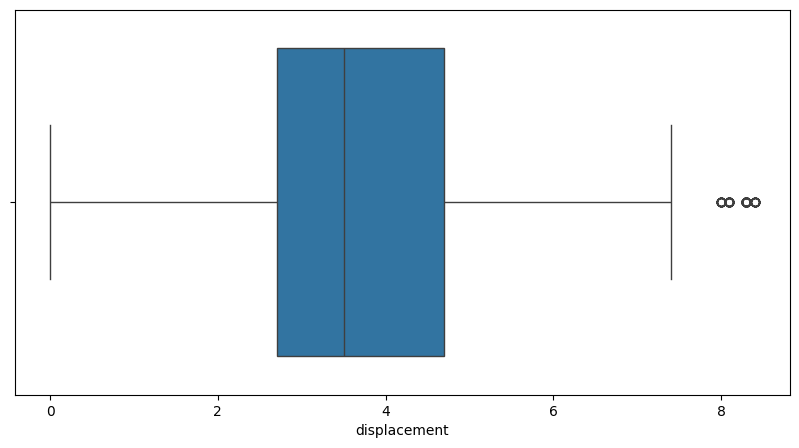

In [68]:
# Plot the distribution of the displacement
plt.figure(figsize=(10, 5))
sns.boxplot(data=cleaned_cars, x="displacement")

In [69]:
# Function to extract if the engine is turbocharged
def has_turbo(engine):
    engine = engine.lower()  # Convert to lowercase for easy matching
    if 'twin turbo' in engine:
        return 2
    if 'turbo' in engine or 'gdti' in engine or 'tfsi' in engine:
        return 1
    else:
        return 0

# Apply the function to create a new column 'transmission_type'
cleaned_cars['turbo'] = cleaned_cars['engine'].apply(has_turbo)


<Axes: xlabel='turbo', ylabel='count'>

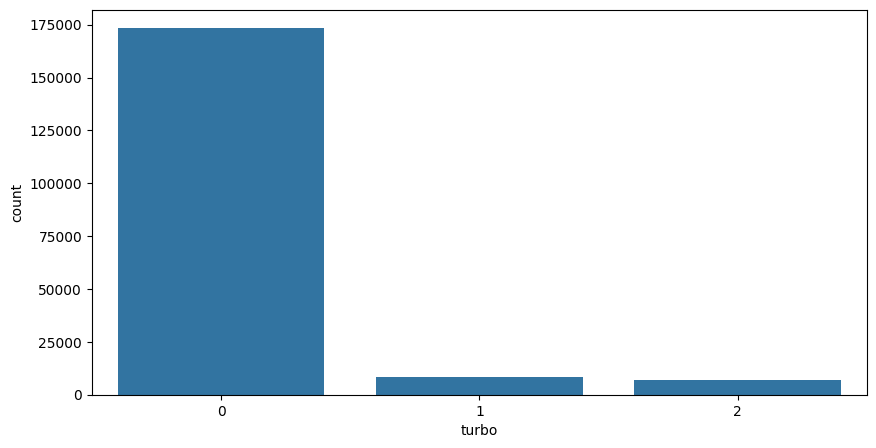

In [70]:
# Plot the distribution of the turbo
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, x="turbo")

**accident**

To study the feature "accident", it's important to answer some questions:

- <span style="color:blue">How many used vehicles have been involved in accidents? </span>

In [71]:
# Replace missing values with not mentioned
cleaned_cars['accident'] = cleaned_cars['accident'].fillna('Not mentioned')

<Axes: xlabel='count', ylabel='accident'>

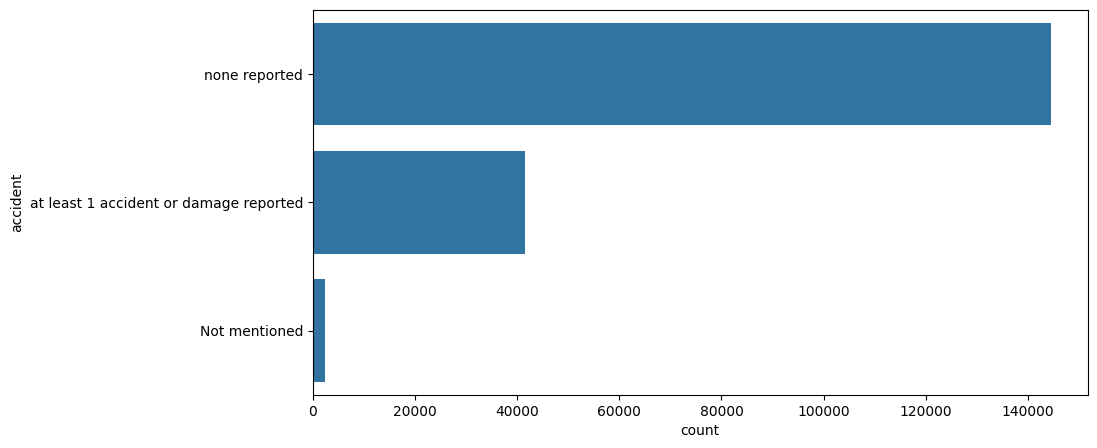

In [72]:
# Plot the distribution of accident
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="accident")

<Axes: xlabel='accident', ylabel='price'>

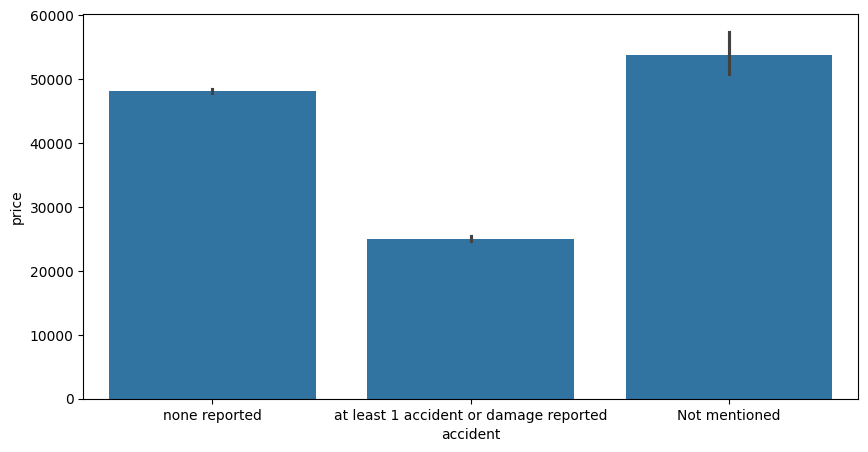

In [73]:
# Plot the average price per accident
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="accident", y="price")

As we can see, a car with at least 1 accident or damage reported has a reduce price

In [74]:
# accident_cat
accident_cat = cleaned_cars['accident'].unique()
accident_cat

array(['none reported', 'at least 1 accident or damage reported',
       'Not mentioned'], dtype=object)

**Clean_title**

To study the feature "clean_title", it's important to answer some questions:

- <span style="color:blue">How many used cars have a clean title? </span>

In [75]:
# Replace missing values with not mentioned
cleaned_cars['clean_title'] = cleaned_cars['clean_title'].fillna('not mentioned')

<Axes: xlabel='count', ylabel='clean_title'>

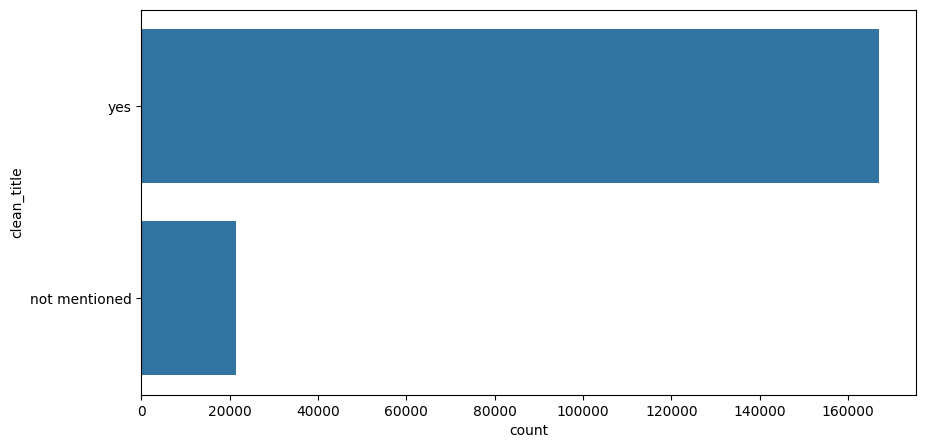

In [76]:
# Plot the distribution of accident
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="clean_title")

<Axes: xlabel='clean_title', ylabel='price'>

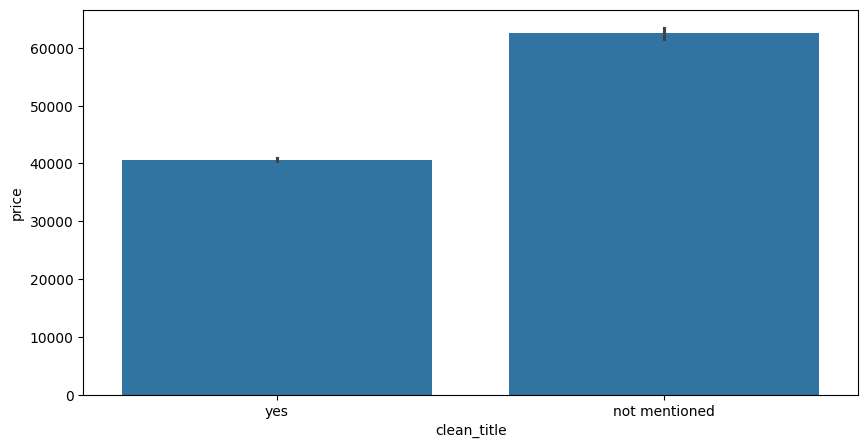

In [77]:
# Plot the average price per accident
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="clean_title", y="price")

In [104]:
# transform yes and no to 1 and 0
def has_clean_title(clean_title):
    clean_title = clean_title.lower()  # Convert to lowercase for easy matching
    if 'yes' in clean_title:
        return 1
    else:
        return 0

cleaned_cars['clean_title_nw'] = cleaned_cars['clean_title'].apply(has_clean_title)

<Axes: xlabel='clean_title_nw', ylabel='price'>

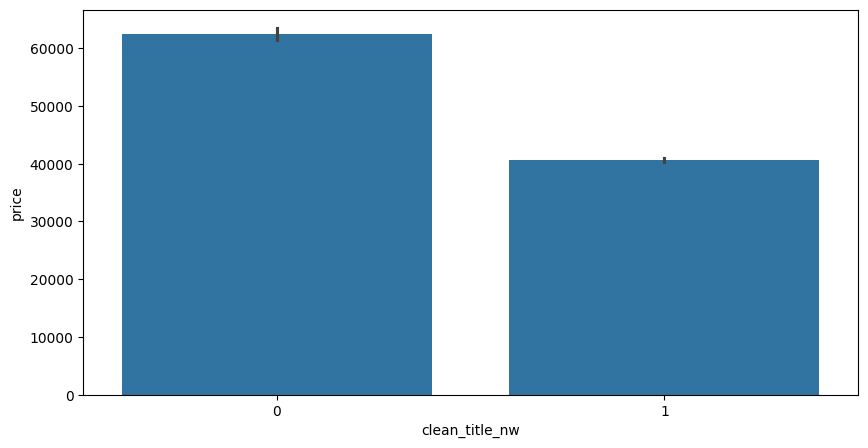

In [105]:
# Plot the average price per accident
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="clean_title_nw", y="price")

**Ext_col**

To study the feature "ext_col", it's important to answer some questions:

- <span style="color:blue">How many colours are used on car exteriors?  </span>
- <span style="color:blue">Does the color impact the price </span>

In [79]:
# Number of ext_col
ext_col = cleaned_cars['ext_col'].unique()
print("The number of ext_col are", len(ext_col))

The number of ext_col are 317


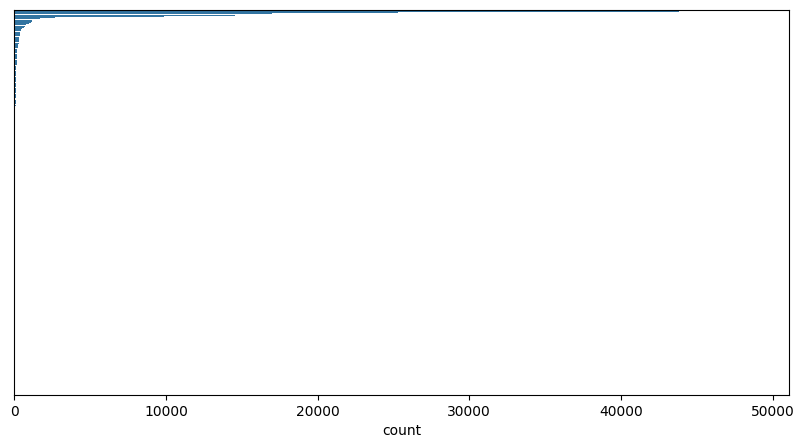

In [80]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="ext_col", order=cleaned_cars['ext_col'].value_counts().index).yaxis.set_visible(False)

In [81]:
# Create a new column to add the category 'other' for brands with less than 20% of the average number of models
avg_ext_col= cleaned_cars['ext_col'].value_counts().mean()
ext_col_counts = cleaned_cars['ext_col'].value_counts()
other_ext_col = ext_col_counts[ext_col_counts <= (avg_ext_col*0.5)].index
cleaned_cars['ext_col_nw'] = cleaned_cars['ext_col'].replace(other_ext_col, 'other')

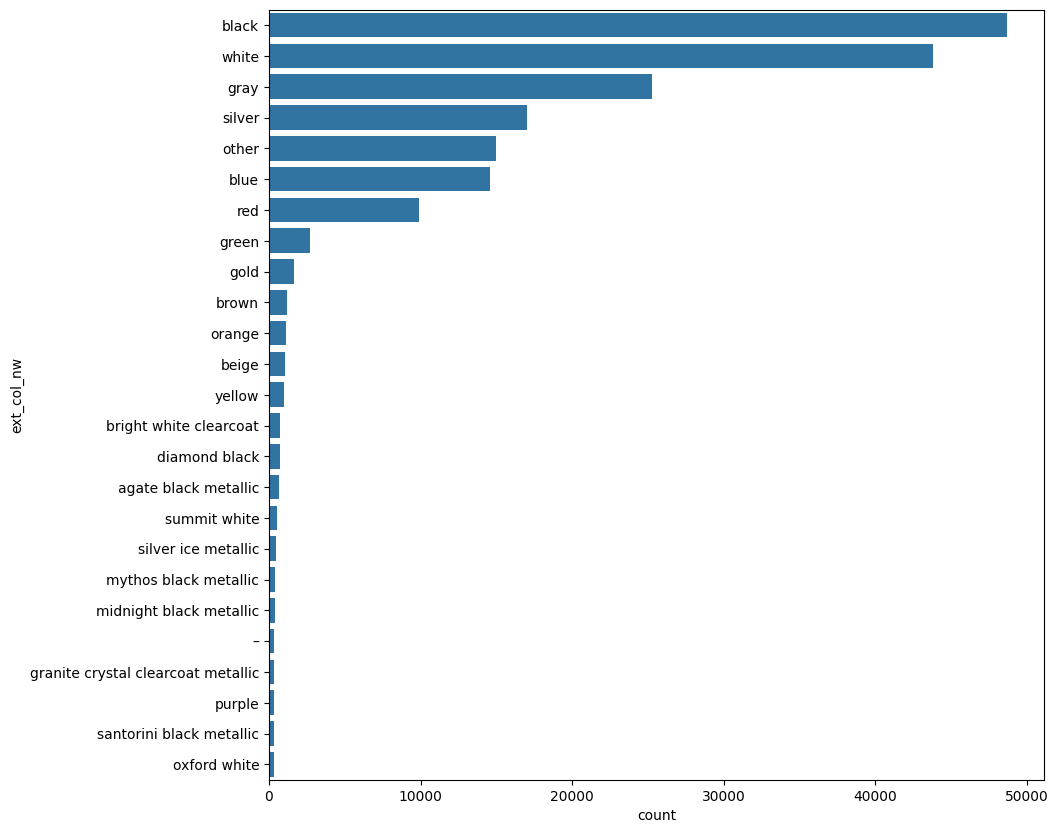

In [82]:
plt.figure(figsize=(10, 10))
sns.countplot(data=cleaned_cars, y="ext_col_nw", order=cleaned_cars['ext_col_nw'].value_counts().index).yaxis

<Axes: xlabel='price', ylabel='ext_col_nw'>

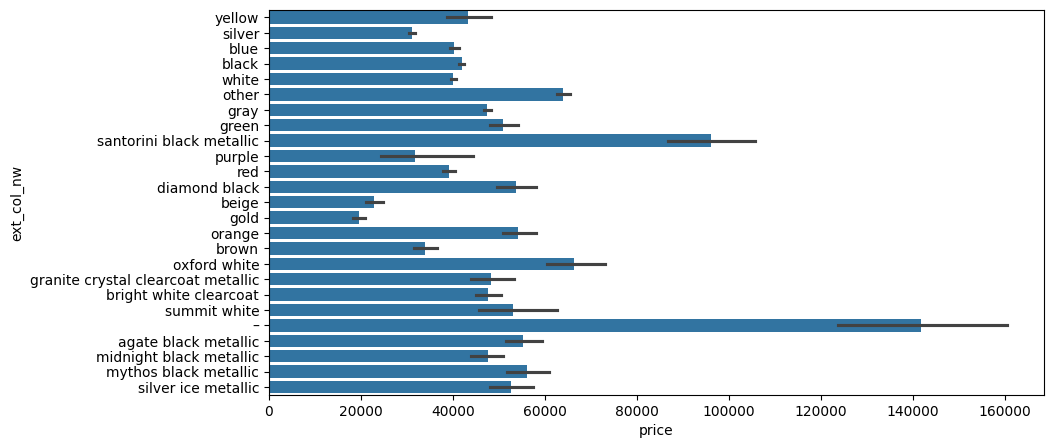

In [83]:
# Plot the average price per interior color
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, y="ext_col_nw", x="price")

In [84]:
# ext_col
ext_col_cat = cleaned_cars['ext_col_nw'].unique()
ext_col_cat

array(['yellow', 'silver', 'blue', 'black', 'white', 'other', 'gray',
       'green', 'santorini black metallic', 'purple', 'red',
       'diamond black', 'beige', 'gold', 'orange', 'brown',
       'oxford white', 'granite crystal clearcoat metallic',
       'bright white clearcoat', 'summit white', '–',
       'agate black metallic', 'midnight black metallic',
       'mythos black metallic', 'silver ice metallic'], dtype=object)

**Int_col**

To study the feature "int_col", it's important to answer some questions:

- <span style="color:blue">How many colours are used on car interiors?  </span>
- <span style="color:blue">Does the color impact the price </span>

In [85]:
# Number of int_col
int_col = cleaned_cars['int_col'].unique()
print("The number of int_col are", len(int_col))

The number of int_col are 152


In [86]:
int_col

array(['gray', 'beige', 'black', '–', 'blue', 'white', 'red', 'brown',
       'dark galvanized', 'parchment.', 'boulder', 'orange',
       'medium earth gray', 'ebony', 'canberra beige', 'jet black',
       'silver', 'light platinum / jet black', 'macchiato/magmagrey',
       'gold', 'cloud', 'rioja red', 'global black', 'green',
       'medium stone', 'navy pier', 'dark ash', 'portland', 'sandstone',
       'canberra beige/black', 'diesel gray / black', 'sarder brown',
       'black onyx', 'white / brown', 'black/gun metal', 'slate',
       'satin black', 'macchiato beige/black', 'charcoal',
       'black / express red', 'cappuccino', 'aragon brown', 'parchment',
       'oyster w/contrast', 'adrenaline red', 'ebony.', 'shara beige',
       'graystone', 'pearl beige', 'nero ade', 'graphite',
       'tan/ebony/ebony', 'charcoal black', 'medium ash gray',
       'ebony black', 'light titanium', 'sakhir orange', 'tan',
       'rock gray', 'brandy', 'carbon black', 'amber',
       'black w

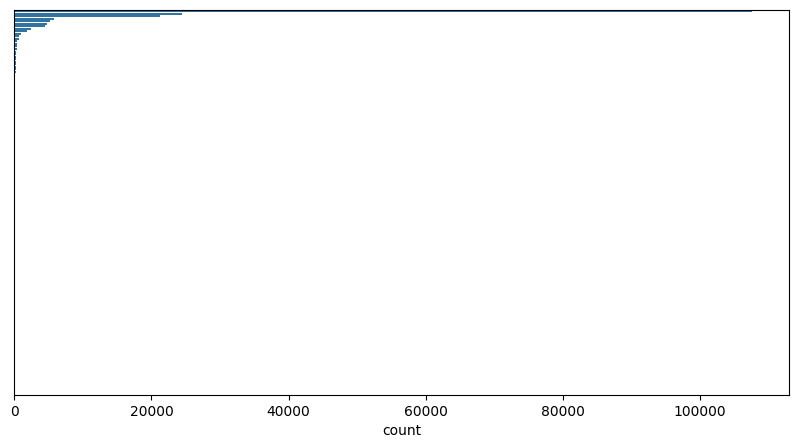

In [87]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="int_col", order=cleaned_cars['int_col'].value_counts().index).yaxis.set_visible(False)

In [88]:
# Create a new column to add the category 'other' for brands with less than 20% of the average number of models
avg_int_col= cleaned_cars['int_col'].value_counts().mean()
int_col_counts = cleaned_cars['int_col'].value_counts()
other_int_col = int_col_counts[int_col_counts <= (avg_int_col)].index
cleaned_cars['int_col_nw'] = cleaned_cars['int_col'].replace(other_int_col, 'other')

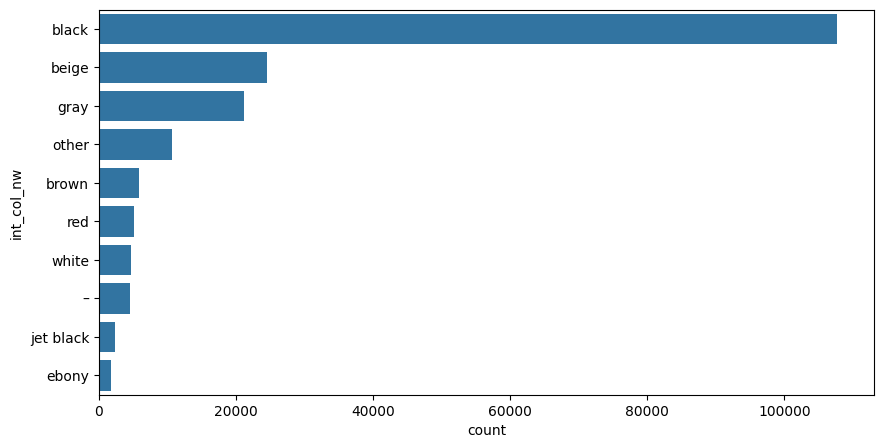

In [89]:
plt.figure(figsize=(10, 5))
sns.countplot(data=cleaned_cars, y="int_col_nw", order=cleaned_cars['int_col_nw'].value_counts().index).yaxis

<Axes: xlabel='int_col_nw', ylabel='price'>

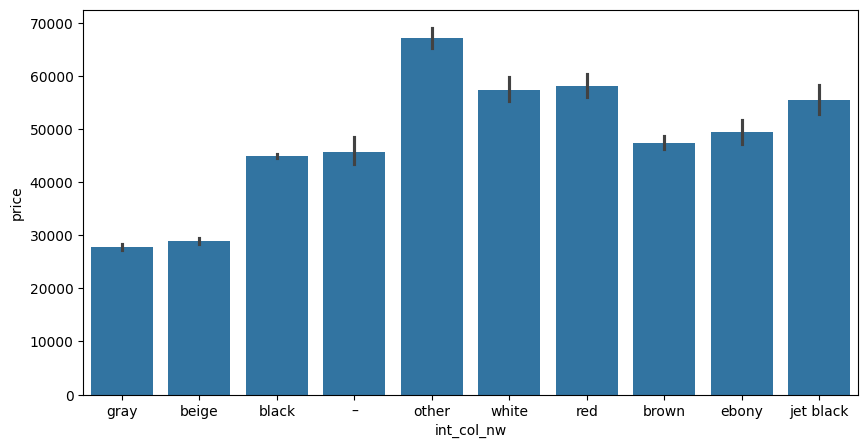

In [90]:
# Plot the average price per interior color
plt.figure(figsize=(10, 5))
sns.barplot(data=cleaned_cars, x="int_col_nw", y="price")

We can't combine unknown color cars with others because there is a big diffence between average price of those 2 informations.

In [91]:
# int_col
int_col_cat = cleaned_cars['int_col_nw'].unique()
int_col_cat

array(['gray', 'beige', 'black', '–', 'other', 'white', 'red', 'brown',
       'ebony', 'jet black'], dtype=object)

## Data Processing

In [106]:
cleaned_cars.columns

Index(['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine',
       'transmission', 'ext_col', 'int_col', 'accident', 'clean_title',
       'price', 'brand_nw', 'model_nw', 'seniority', 'fuel_type_nw',
       'transmission_type', 'num_speeds', 'additional_details', 'hp',
       'cylinders', 'displacement', 'turbo', 'clean_title_nw', 'ext_col_nw',
       'int_col_nw'],
      dtype='object')

In [225]:
X = cleaned_cars[['brand_nw', 'model_nw', 'seniority', 'milage', 'fuel_type_nw', 'accident', 
                  'clean_title_nw', 'transmission_type', 'num_speeds', 'additional_details', 
                  'hp', 'cylinders', 'displacement', 'turbo', 'ext_col_nw', 'int_col_nw']]
y = cleaned_cars['price']

In [242]:
# Q1 and Q3 of the price
Q1 = cleaned_cars['price'].quantile(0.25)
median = cleaned_cars['price'].median()
Q3 = cleaned_cars['price'].quantile(0.75)
pseudo_max = Q3 + 1.5*(Q3 - Q1)

In [243]:
# Create bins for the price
price_bins = pd.cut(y, bins=[0, Q1, median, Q3, pseudo_max, np.inf])

# Split the data into training and testing sets stratified by the price bins
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=price_bins)

In [244]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150786 entries, 110573 to 18245
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   brand_nw            150786 non-null  object 
 1   model_nw            150786 non-null  object 
 2   seniority           150786 non-null  int64  
 3   milage              150786 non-null  int64  
 4   fuel_type_nw        150786 non-null  object 
 5   accident            150786 non-null  object 
 6   clean_title_nw      150786 non-null  int64  
 7   transmission_type   150786 non-null  object 
 8   num_speeds          150786 non-null  int64  
 9   additional_details  150786 non-null  int64  
 10  hp                  150786 non-null  float64
 11  cylinders           150786 non-null  int64  
 12  displacement        150786 non-null  float64
 13  turbo               150786 non-null  int64  
 14  ext_col_nw          150786 non-null  object 
 15  int_col_nw          150786 non-null

In [245]:

column_transformer = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['brand_nw', 'model_nw', 'fuel_type_nw', 'accident', 'transmission_type', 'ext_col_nw', 'int_col_nw']),  # One-hot encode
        ('minmax', MinMaxScaler(), ['hp', 'num_speeds', 'turbo']),  # Normalize
        ('robust', RobustScaler(), ['seniority', 'milage']),  # Normalize
        ('standard', StandardScaler(), ['cylinders', 'displacement'])  # Normalize
    ],
    remainder='passthrough',
    sparse_threshold=1.0
)

X_transformed = column_transformer.fit_transform(X_train)

scaler_y = RobustScaler()
y_train_reshape = y_train.values.reshape(-1,1)
y_train_norm = scaler_y.fit_transform(y_train_reshape)  # Normalize y

<Axes: >

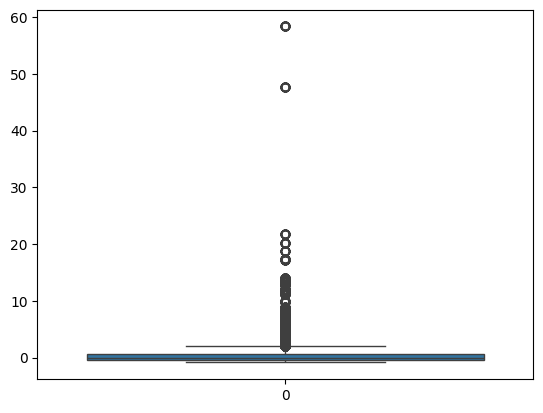

In [303]:
sns.boxplot(y_train_norm)

In [366]:
y_train_norm.std()

np.float64(1.9025450678440974)

In [365]:
beta = 0.5*y_train_norm.std()
beta

np.float64(0.9512725339220487)

## Train Model

In [246]:
# Train a linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

model = LinearRegression()
model.fit(X_transformed, y_train_norm)

y_train_pred = model.predict(X_transformed)
print("The train mean squared error is", root_mean_squared_error(y_train_norm, y_train_pred))

# Evaluate the model
X_test_transformed = column_transformer.transform(X_test)
y_test_reshape = y_test.values.reshape(-1,1)
y_test_norm = scaler_y.transform(y_test_reshape)
y_test_pred = model.predict(X_test_transformed)
print("The test mean squared error is", root_mean_squared_error(y_test_norm, y_test_pred))

The train mean squared error is 1.6851777429007428
The test mean squared error is 1.7596114958179458


In [248]:
# inverse transform
y_train_pred_inv = scaler_y.inverse_transform(y_train_pred)
y_train_inv = scaler_y.inverse_transform(y_train_norm)

# RMSE
print("The train mean squared error is", root_mean_squared_error(y_train_inv, y_train_pred_inv))

# inverse transform
y_test_pred_inv = scaler_y.inverse_transform(y_test_pred)
y_test_inv = scaler_y.inverse_transform(y_test_norm)

# RMSE
print("The test mean squared error is", root_mean_squared_error(y_test_inv, y_test_pred_inv))

The train mean squared error is 55442.34774143444
The test mean squared error is 57891.21821241043


In [152]:
# Polynomial regression
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_poly_train = poly.fit_transform(X_transformed)

model = LinearRegression()
model.fit(X_poly_train, y_train)

y_train_pred = model.predict(X_poly_train)
print("The train mean squared error is", root_mean_squared_error(y_train, y_train_pred))

# Evaluate the model
X_test_transformed = column_transformer.transform(X_test)
X_poly_test = poly.fit_transform(X_test_transformed)
y_test_pred = model.predict(X_poly_test)
print("The test mean squared error is", root_mean_squared_error(y_test, y_test_pred))

The train mean squared error is 46681.03958871187
The test mean squared error is 78447.72803117316


In [131]:
# Train 
from sklearn.linear_model import LinearRegression, Ridge

model = Ridge(alpha=100.0)
model.fit(X_transformed, y_train)

y_train_pred = model.predict(X_transformed)
print("The train mean squared error is", root_mean_squared_error(y_train, y_train_pred))

# Evaluate the model
X_test_transformed = column_transformer.transform(X_test)
y_test_pred = model.predict(X_test_transformed)
print("The test mean squared error is", root_mean_squared_error(y_test, y_test_pred))

The train mean squared error is 56250.57245309702
The test mean squared error is 56334.72930357932


In [166]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.01, max_depth=6, max_features=288)
model.fit(X_transformed, y_train)

y_train_pred = model.predict(X_transformed)
print("The train mean squared error is", root_mean_squared_error(y_train, y_train_pred))

# Evaluate the model
X_test_transformed = column_transformer.transform(X_test)
y_test_pred = model.predict(X_test_transformed)
print("The test mean squared error is", root_mean_squared_error(y_test, y_test_pred))

The train mean squared error is 56692.64778423188
The test mean squared error is 57616.96827882164


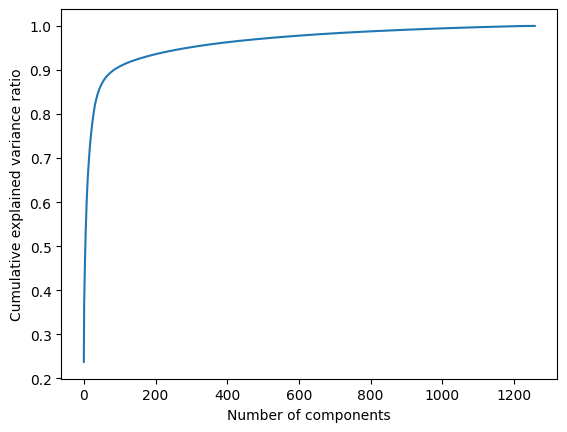

In [249]:
# PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_transformed)

# Visualize the explained variance ratio
cumulative_variance_ratio = np.cumsum(pca.explained_variance_ratio_)
plt.plot(cumulative_variance_ratio)
plt.xlabel('Number of components')
plt.ylabel('Cumulative explained variance ratio')
plt.show()

In [250]:
num_components = np.argmax(cumulative_variance_ratio >= 0.95) + 1
print(f'{num_components} components are needed to explain 95% of the variance')

288 components are needed to explain 95% of the variance


In [280]:
num_components = np.argmax(cumulative_variance_ratio >= 0.99) + 1
print(f'{num_components} components are needed to explain 97.5% of the variance')

862 components are needed to explain 97.5% of the variance


In [492]:
# Neural network
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class NeuralNet(torch.nn.Module):
     def __init__(self, D_in, H1, H2, H3, D_out):
        super(NeuralNet, self).__init__()
        self.linear1 = torch.nn.Linear(D_in, H1)
        self.dropout1 = nn.Dropout(0.3)  
        self.linear2 = torch.nn.Linear(H1, H2)
        self.dropout2 = nn.Dropout(0.3) 
        self.linear3 = torch.nn.Linear(H2, H3)
        self.dropout3 = nn.Dropout(0.3)
        self.linear5 = torch.nn.Linear(H3, D_out)
     def forward(self, x):
        h1 = torch.relu(self.linear1(x))
        h1 = self.dropout1(h1)
        h2 = torch.relu(self.linear2(h1))
        h2 = self.dropout2(h2)
        h3 = torch.relu(self.linear3(h2))
        h3 = self.dropout3(h3)
        y_pred = self.linear5(h3)
        return y_pred
     
# Convert data to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_transformed)
Y_train_tensor = torch.FloatTensor(y_train_norm)
X_test_tensor = torch.FloatTensor(X_test_transformed)
Y_test_tensor = torch.FloatTensor(y_test_norm)

# Create a Dataset and DataLoader
batch_size = 16
dataset = TensorDataset(X_train_tensor, Y_train_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

D_in, H1, H2, H3, D_out = 1259, 576, 288, 16, 1
num_epochs = 25

model = NeuralNet(D_in, H1, H2, H3, D_out)
criterion = nn.SmoothL1Loss(beta=10.6058799091818) # nn.MSELoss() nn.SmoothL1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)

In [493]:
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for batch_inputs, batch_targets in dataloader:
        # Training phase
        model.train()
        y_pred_train = model(batch_inputs)
        train_loss = criterion(y_pred_train, batch_targets)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        epoch_loss += train_loss.item()
        
    # Validation phase
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_test_tensor)
        val_loss = criterion(y_pred_val, Y_test_tensor)
    
    # Average loss for the epoch
    print(f'Epoch [{epoch+1}/{num_epochs}] - '
            f'Train Loss: {epoch_loss / len(dataloader):.4f}, Val Loss: {val_loss.item():.4f}')

Epoch [1/25] - Train Loss: 0.1021, Val Loss: 0.0985
Epoch [2/25] - Train Loss: 0.0944, Val Loss: 0.0970
Epoch [3/25] - Train Loss: 0.0930, Val Loss: 0.0961
Epoch [4/25] - Train Loss: 0.0923, Val Loss: 0.0956
Epoch [5/25] - Train Loss: 0.0919, Val Loss: 0.0954
Epoch [6/25] - Train Loss: 0.0914, Val Loss: 0.0952
Epoch [7/25] - Train Loss: 0.0911, Val Loss: 0.0950
Epoch [8/25] - Train Loss: 0.0910, Val Loss: 0.0948
Epoch [9/25] - Train Loss: 0.0905, Val Loss: 0.0948
Epoch [10/25] - Train Loss: 0.0907, Val Loss: 0.0946
Epoch [11/25] - Train Loss: 0.0903, Val Loss: 0.0947
Epoch [12/25] - Train Loss: 0.0902, Val Loss: 0.0945
Epoch [13/25] - Train Loss: 0.0898, Val Loss: 0.0945
Epoch [14/25] - Train Loss: 0.0899, Val Loss: 0.0944
Epoch [15/25] - Train Loss: 0.0897, Val Loss: 0.0943
Epoch [16/25] - Train Loss: 0.0898, Val Loss: 0.0946
Epoch [17/25] - Train Loss: 0.0897, Val Loss: 0.0944
Epoch [18/25] - Train Loss: 0.0894, Val Loss: 0.0942
Epoch [19/25] - Train Loss: 0.0896, Val Loss: 0.0942
Ep

In [426]:
print(y_train_norm.mean())
print(y_train_norm.std())
print(y_train_norm.min())
print(y_train_norm.max())

0.3732316731250235
1.9025450678440974
-0.8753191489361702
58.36465045592705


In [430]:
pseudo_max*y_train_norm.std()/y_train_norm.mean()

np.float64(10.6058799091818)

In [494]:
Y_pred = model(X_train_tensor)
y_train_pred = Y_pred.detach().numpy()
print("The train mean squared error is", root_mean_squared_error(y_train, y_train_pred))

# Evaluate the model
Y_pred = model(X_test_tensor)
y_test_pred = Y_pred.detach().numpy()
print("The test mean squared error is", root_mean_squared_error(y_test, y_test_pred))

The train mean squared error is 75983.8771314227
The test mean squared error is 77654.46317748369


In [495]:
# inverse transform
y_train_pred_inv = scaler_y.inverse_transform(y_train_pred)
y_train_inv = scaler_y.inverse_transform(y_train_norm)

# RMSE
print("The train mean squared error is", root_mean_squared_error(y_train_inv, y_train_pred_inv))

# inverse transform
y_test_pred_inv = scaler_y.inverse_transform(y_test_pred)
y_test_inv = scaler_y.inverse_transform(y_test_norm)

# RMSE
print("The test mean squared error is", root_mean_squared_error(y_test_inv, y_test_pred_inv))

The train mean squared error is 54253.58046816994
The test mean squared error is 56709.664345895144


## Submission

In [119]:
# Submission
test_data = pd.read_csv('data/test.csv')
test_data.set_index('id', inplace=True)
test_data.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
id,,,,,,,,,,,
188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


In [120]:
# Apply the same data cleaning steps to the test data
# Put objet column in lower case
test_data['brand'] = test_data['brand'].str.lower()
test_data['model'] = test_data['model'].str.lower()
test_data['fuel_type'] = test_data['fuel_type'].str.lower()
test_data['engine'] = test_data['engine'].str.lower()
test_data['transmission'] = test_data['transmission'].str.lower()
test_data['ext_col'] = test_data['ext_col'].str.lower()
test_data['int_col'] = test_data['int_col'].str.lower()
test_data['accident'] = test_data['accident'].str.lower()
test_data['clean_title'] = test_data['clean_title'].str.lower()

In [121]:
test_data['brand_nw'] = test_data['brand'].apply(lambda x: x if x in brand_cat else 'other')
test_data['model_nw'] = test_data['model'].apply(lambda x: x if x in model_cat else 'other')
test_data['seniority'] = 2024 - test_data['model_year']
test_data['fuel_type_nw'] = test_data['fuel_type'].apply(extract_fuel_type)
test_data['transmission_type'] = test_data['transmission'].apply(extract_transmission_type)
test_data['num_speeds'] = test_data['transmission'].apply(extract_number_of_speeds)
test_data['additional_details'] = test_data['transmission'].apply(has_additionnal)
test_data['hp'] = test_data['engine'].apply(extract_hp)
test_data['cylinders'] = test_data['engine'].apply(extract_cylinders)
test_data['displacement'] = test_data['engine'].apply(extract_displacement)
test_data['turbo'] = test_data['engine'].apply(has_turbo)
test_data['accident'] = test_data['accident'].fillna('Not mentioned')
test_data['clean_title'] = test_data['clean_title'].fillna('not mentioned')
test_data['clean_title_nw'] = test_data['clean_title'].apply(has_clean_title)
test_data['ext_col_nw'] = test_data['ext_col'].apply(lambda x: x if x in ext_col_cat else 'other')
test_data['int_col_nw'] = test_data['int_col'].apply(lambda x: x if x in int_col_cat else 'other')

In [205]:
X_submit = test_data[['brand_nw', 'model_nw', 'seniority', 'milage', 'fuel_type_nw', 'accident', 
                  'clean_title_nw', 'transmission_type', 'num_speeds', 'additional_details', 
                  'hp', 'cylinders', 'displacement', 'turbo', 'ext_col_nw', 'int_col_nw']]
X_submit_transformed = column_transformer.transform(X_submit)

In [148]:
y_submit_pred = model.predict(X_submit_transformed)
y_submit_pred

array([26642.96651542, 62498.41316099, 50457.51482756, ...,
       31911.28701643, 25160.23983933, 39898.95989105])

In [ ]:
# Polynomial regression
y_submit_pred = model.predict(poly.transform(X_submit_transformed))
y_submit_pred

In [ ]:
# Save submission
# Create a DataFrame with IDs and Predictions
results_df = pd.DataFrame({
    'id': test_data.index,
    'price': y_submit_pred
})

results_df.to_csv('submission_used_car_prices.csv', index=False)

In [496]:
# NN
X_submit_tensor = torch.FloatTensor(X_submit_transformed)
Y_pred = model(X_submit_tensor)
y_submit_pred = Y_pred.detach().numpy()
y_submit_pred = scaler_y.inverse_transform(y_submit_pred)
y_submit_pred

array([[19857.463],
       [66508.81 ],
       [50645.656],
       ...,
       [19003.781],
       [17240.445],
       [35968.535]], dtype=float32)

In [497]:
# Save submission
# Create a DataFrame with IDs and Predictions
results_df = pd.DataFrame({
    'id': test_data.index,
    'price': y_submit_pred.flatten()
})

results_df.to_csv('submission_used_car_prices.csv', index=False)